In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('placement.csv')
print(df.shape)
df.head()


(100, 3)


,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


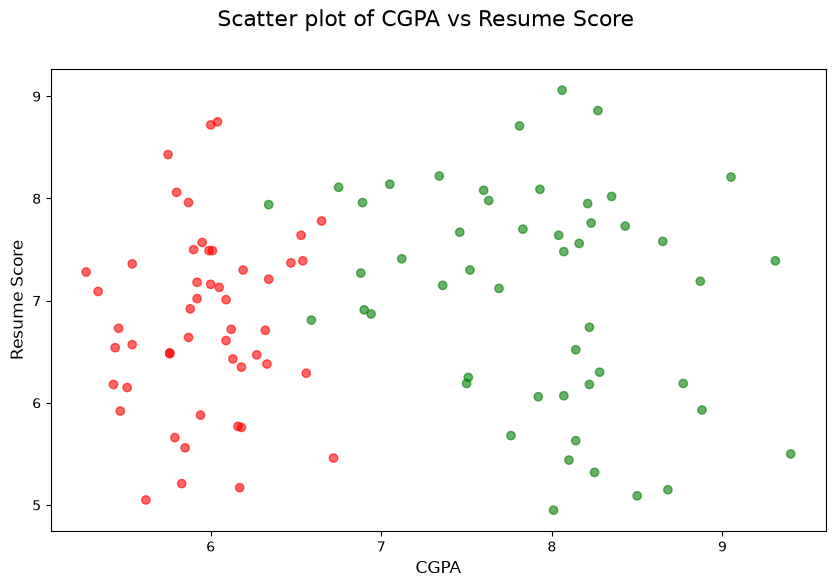

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['cgpa'], df['resume_score'], color=df['placed'].map({1: 'green', 0: 'red'}), alpha=0.6)
fig.suptitle('Scatter plot of CGPA vs Resume Score', fontsize=16)
ax.set_xlabel('CGPA', fontsize=12)
ax.set_ylabel('Resume Score', fontsize=12)

plt.show()

<Axes: xlabel='cgpa', ylabel='resume_score'>

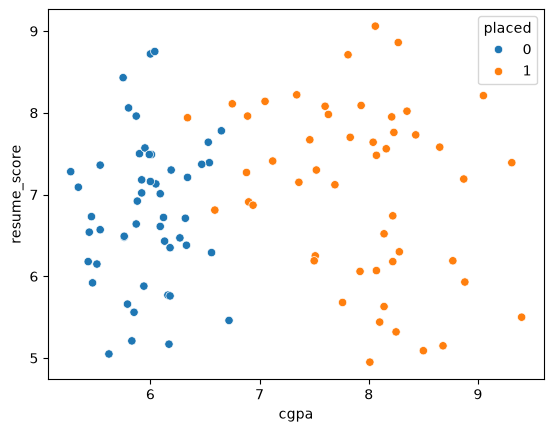

In [16]:
sns.scatterplot(data=df, x='cgpa', y='resume_score', hue='placed')

In [17]:
X= df.iloc[:,0:2]
Y= df.iloc[:,-1]

In [23]:
from sklearn.linear_model import Perceptron
p = Perceptron()
p.fit(X,Y)
p.coef_, p.intercept_

(array([[ 40.26, -36.  ]]), array([-25.]))

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

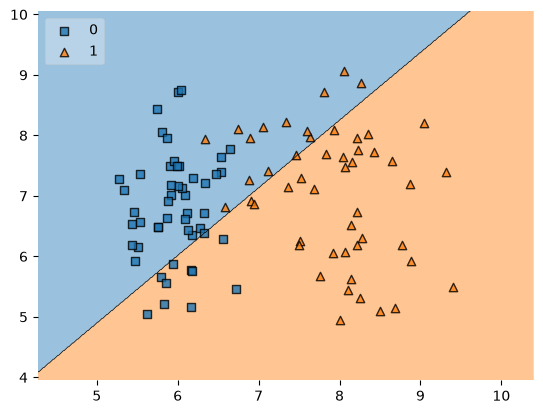

In [25]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values, Y.values, clf=p, legend=2)


<h1>Building from Scratch</h1>

In [11]:
from sklearn.datasets import make_classification
X, Y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_clusters_per_class=1, n_classes=2, random_state=41, hypercube=False, class_sep=10)


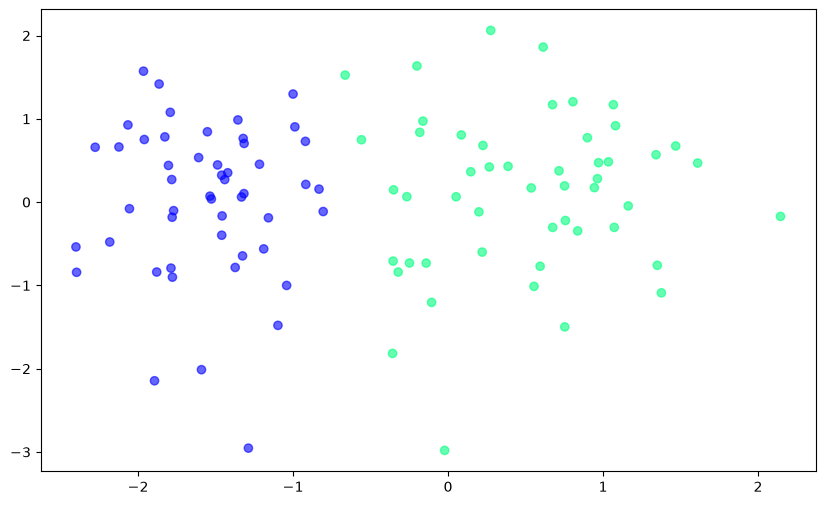

In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X[:, 0], X[:, 1], c=Y, cmap='winter', alpha=0.6)

In [13]:
print(X)
print(Y)


[[ 0.19924745 -0.11697552]
 [-0.24882029 -0.73115232]
 [-0.3544904  -0.7081059 ]
 [-1.59086506 -2.01199214]
 [-0.20083951  1.63493163]
 [-0.83241122  0.15599044]
 [-1.79207014  1.07782053]
 [ 0.0856607   0.80626713]
 [-0.55865299  0.74859527]
 [-1.95974262  0.75152794]
 [-1.77828947 -0.90114581]
 [-1.77985853 -0.1815243 ]
 [-0.02194151 -2.98092432]
 [ 0.80563431  1.20500136]
 [-1.82701214  0.78302407]
 [ 0.38730728  0.42968688]
 [-0.14108668 -0.73229726]
 [-1.87955941 -0.83930476]
 [-0.18232911  0.83727062]
 [-1.77059533 -0.10255323]
 [-2.27658028  0.65867001]
 [-2.06519502  0.92649819]
 [-1.31690551  0.10216193]
 [ 1.61043259  0.46886454]
 [-1.21650394  0.45432938]
 [ 0.6139723   1.8613386 ]
 [-1.78760957 -0.79255991]
 [-1.04149161 -1.0004391 ]
 [-2.40067584 -0.53814137]
 [-1.80383452  0.44027716]
 [-1.44075613  0.27047889]
 [ 1.34989978 -0.75869267]
 [ 0.22520167  0.6802322 ]
 [ 0.53688527  0.17018845]
 [ 0.55483459 -1.01121977]
 [-0.32178185 -0.8394709 ]
 [-0.98821248  0.90327412]
 

In [14]:
import numpy as np
print(np.insert(X, 0, 1, axis=1))  # Add bias term

[[ 1.          0.19924745 -0.11697552]
 [ 1.         -0.24882029 -0.73115232]
 [ 1.         -0.3544904  -0.7081059 ]
 [ 1.         -1.59086506 -2.01199214]
 [ 1.         -0.20083951  1.63493163]
 [ 1.         -0.83241122  0.15599044]
 [ 1.         -1.79207014  1.07782053]
 [ 1.          0.0856607   0.80626713]
 [ 1.         -0.55865299  0.74859527]
 [ 1.         -1.95974262  0.75152794]
 [ 1.         -1.77828947 -0.90114581]
 [ 1.         -1.77985853 -0.1815243 ]
 [ 1.         -0.02194151 -2.98092432]
 [ 1.          0.80563431  1.20500136]
 [ 1.         -1.82701214  0.78302407]
 [ 1.          0.38730728  0.42968688]
 [ 1.         -0.14108668 -0.73229726]
 [ 1.         -1.87955941 -0.83930476]
 [ 1.         -0.18232911  0.83727062]
 [ 1.         -1.77059533 -0.10255323]
 [ 1.         -2.27658028  0.65867001]
 [ 1.         -2.06519502  0.92649819]
 [ 1.         -1.31690551  0.10216193]
 [ 1.          1.61043259  0.46886454]
 [ 1.         -1.21650394  0.45432938]
 [ 1.          0.6139723 

In [40]:
def Perceptron(X, y):
    X = np.insert(X, 0, 1, axis=1)  # Add bias term
    weights = np.zeros(X.shape[1])  # Initialize weights
    learning_rate = 0.1
    for epoch in range(1000):  # Number of epochs
        j = np.random.randint(0,100)
        y_hat = step((np.dot(X[j], weights)))  # Prediction
        error = y[j] - y_hat  # Calculate error
        weights += learning_rate * error * X[j]  # Update weights
    return weights[0], weights[1:]  # Return bias and weights

In [42]:
def step(x):
    return 1 if x >= 0 else 0


In [47]:
intercept, coefficients = Perceptron(X, Y)
print("Intercept:", intercept)
print("Coefficients:", coefficients)

Intercept: 0.30000000000000004
Coefficients: [0.53090315 0.05493775]


In [48]:
m = -coefficients[0] / coefficients[1]
b = -intercept / coefficients[1]

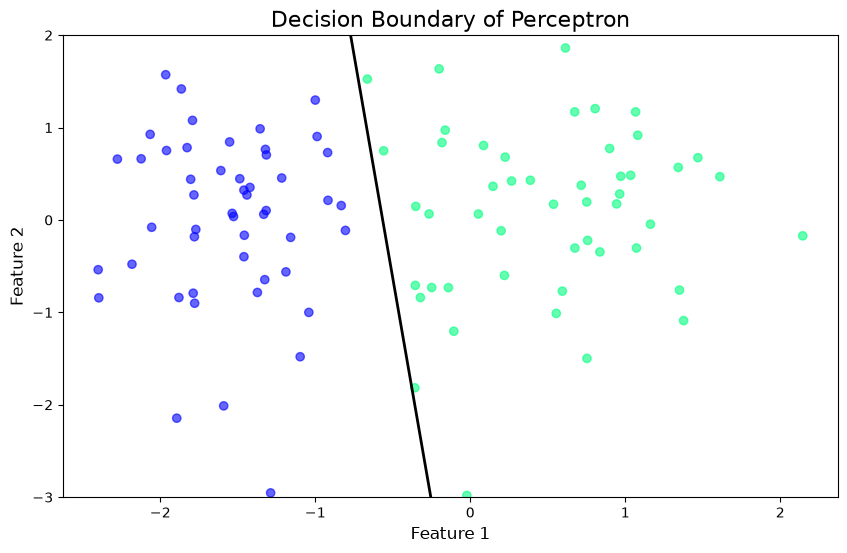

In [54]:
x_input =   np.linspace(-1, 1, 100)
y_input = m * x_input + b

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='winter', alpha=0.6)
plt.plot(x_input, y_input, color='black', linewidth=2)
plt.title('Decision Boundary of Perceptron', fontsize=16)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)   
plt.ylim(-3,2) 

plt.show()

<h1>Drawing Animation</h1>

In [61]:
def perceptron(X,Y):
    m=[]
    b=[]

    X= np.insert(X, 0, 1, axis=1)  # Add bias term
    weights = np.zeros(X.shape[1])  # Initialize weights
    learning_rate = 0.1
    for epoch in range(1000):  # Number of epochs
        j = np.random.randint(0,100)
        y_hat = step((np.dot(X[j], weights)))  # Prediction
        error = Y[j] - y_hat  # Calculate error
        weights += learning_rate * error * X[j]  # Update weights

        m.append(-(weights[1] / weights[2]))
        b.append(-(weights[0] / weights[2]))
    return m, b


In [62]:
m, b = perceptron(X,Y)

In [64]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

x_i = np.arange(-1, 1, 0.1)
y_input = m[0] * x_i + b[0]

ax.scatter(X[:, 0], X[:, 1], c=Y, cmap='winter', alpha=0.6)
line,  = ax.plot(x_i, y_input, color='black', linewidth=2)
plt.ylim(-3,2)

def update(i):
    label = 'Epoch {0}'.format(i+1)
    line.set_ydata(m[i] * x_i + b[i])
    ax.set_xlabel(label)

anim = FuncAnimation(fig, update, frames=200, interval=100, repeat=True)



<IPython.core.display.Javascript object>

<h1>Perceptron Using Proper Loss Function</h1>

In [15]:
def perceptron(X,Y):
    w1=w2=b=1
    lr=0.1

    for j in range(1000):

        for i in range(len(X)):
            Z = w1*X[i][0] + w2*X[i][1] + b

            if Z*Y[i] < 0:
                w1 += lr*Y[i]*X[i][0]
                w2 += lr*Y[i]*X[i][1]
                b += lr*Y[i]

    return w1,w2,b


In [16]:
w1,w2,b = perceptron(X,Y)

In [18]:
m = -w1/w2
c = -b/w2
print(m,c)

-6.108023124170937 -9.250656660875727


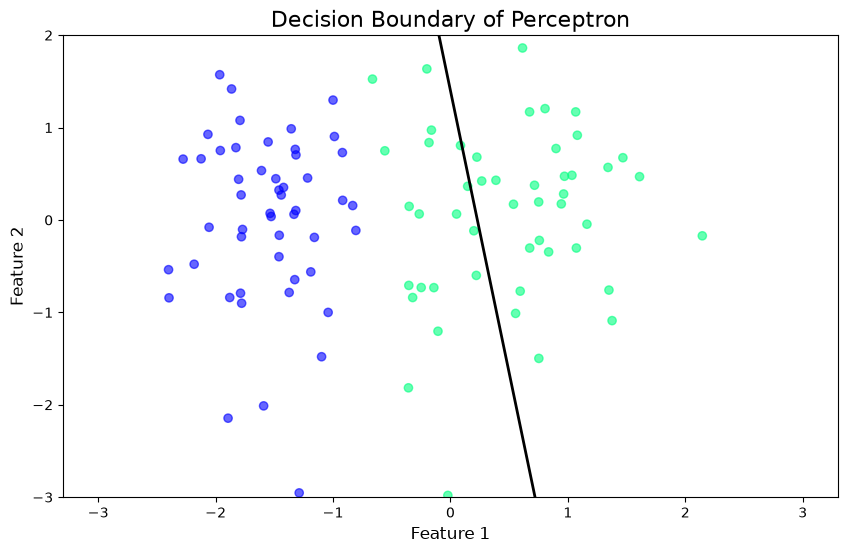

In [19]:
x_input =   np.linspace(-3, 3, 100)
y_input = m * x_input + b

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='winter', alpha=0.6)
plt.plot(x_input, y_input, color='black', linewidth=2)
plt.title('Decision Boundary of Perceptron', fontsize=16)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)   
plt.ylim(-3,2) 

plt.show()



<h1>Problems with Perceptron</h1>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
or_data = pd.DataFrame()
and_data = pd.DataFrame()
xor_data = pd.DataFrame()

In [3]:
or_data['x1'] = [0, 0, 1, 1]
or_data['x2'] = [0, 1, 0, 1]
or_data['y'] = [0, 1, 1, 1]

and_data['x1'] = [0, 0, 1, 1]
and_data['x2'] = [0, 1, 0, 1]
and_data['y'] = [0, 0, 0, 1]

xor_data['x1'] = [0, 0, 1, 1]
xor_data['x2'] = [0, 1, 0, 1]
xor_data['y'] = [0, 1, 1, 0]

In [4]:
or_data

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,1


<Axes: xlabel='x1', ylabel='x2'>

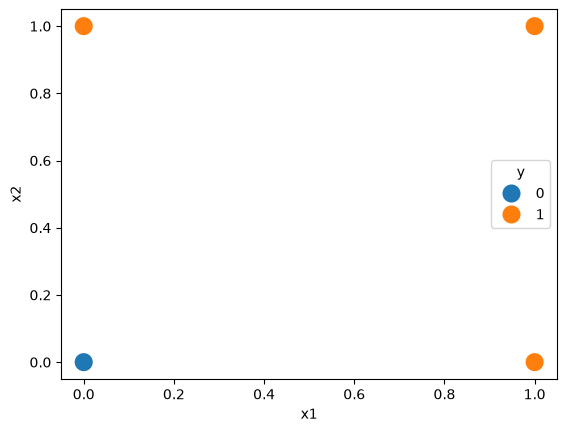

In [9]:
sns.scatterplot(data=or_data, x='x1', y='x2', hue=or_data['y'], s=200)

<Axes: xlabel='x1', ylabel='x2'>

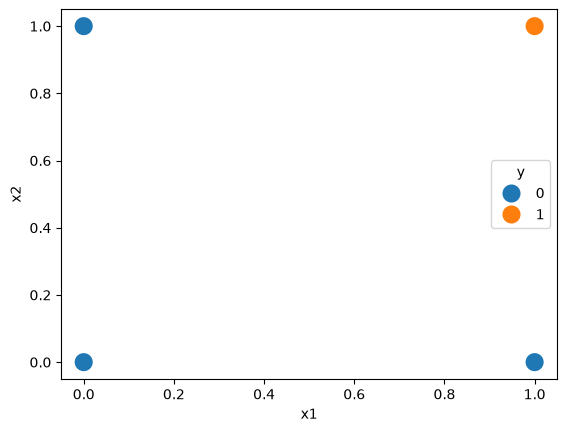

In [10]:
sns.scatterplot(data=and_data, x='x1', y='x2', hue=and_data['y'], s=200)

<Axes: xlabel='x1', ylabel='x2'>

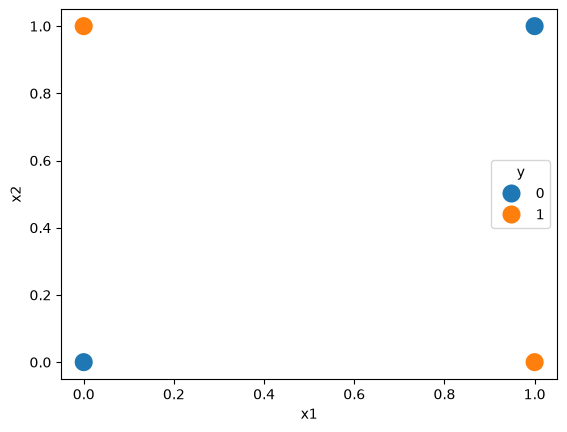

In [11]:
sns.scatterplot(data=xor_data, x='x1', y='x2', hue=xor_data['y'], s=200)

In [12]:
from sklearn.linear_model import Perceptron
clf1 = Perceptron()
clf2 = Perceptron()
clf3 = Perceptron()

In [13]:
clf1.fit(or_data[['x1', 'x2']], or_data['y'])
clf2.fit(and_data[['x1', 'x2']], and_data['y'])
clf3.fit(xor_data[['x1', 'x2']], xor_data['y'])

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [ ]:
clf1.intercept_, clf1.coef_


(array([-1.]), array([[2., 2.]]))

In [15]:
x1 = np.linspace(-1, 1, 5)
y1 = (-clf1.intercept_ - clf1.coef_[0][0] * x1) / clf1.coef_[0][1]

x2 = np.linspace(-1, 1, 5)
y2 = (-clf2.intercept_ - clf2.coef_[0][0] * x2) / clf2.coef_[0][1]

x3 = np.linspace(-1, 1, 5)
y3 = (-clf3.intercept_ - clf3.coef_[0][0] * x3) / clf3.coef_[0][1]



/tmp/ipykernel_2418/2488778681.py:8: RuntimeWarning: invalid value encountered in divide
  y3 = (-clf3.intercept_ - clf3.coef_[0][0] * x3) / clf3.coef_[0][1]


<Axes: xlabel='x1', ylabel='x2'>

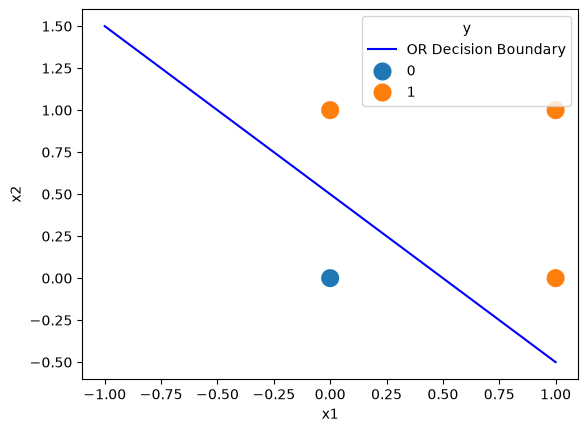

In [16]:
plt.plot(x1, y1, label='OR Decision Boundary', color='blue')
sns.scatterplot(data=or_data, x='x1', y='x2', hue=or_data['y'], s=200)

<Axes: xlabel='x1', ylabel='x2'>

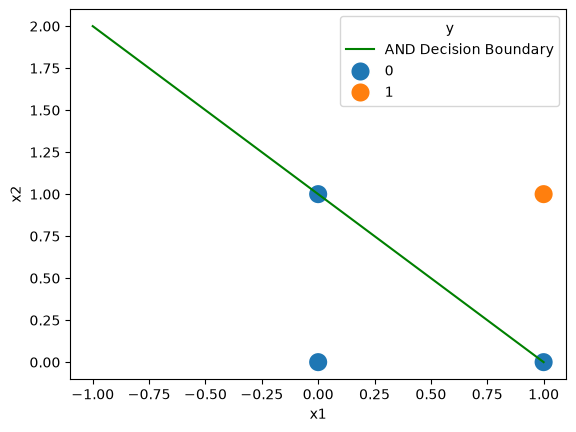

In [17]:
plt.plot(x2, y2, label='AND Decision Boundary', color='green')
sns.scatterplot(data=and_data, x='x1', y='x2', hue=and_data['y'], s=200)

<Axes: xlabel='x1', ylabel='x2'>

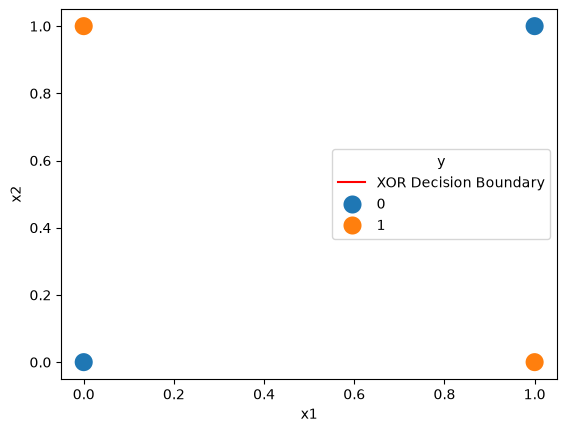

In [18]:
plt.plot(x3, y3, label='XOR Decision Boundary', color='red')
sns.scatterplot(data=xor_data, x='x1', y='x2', hue=xor_data['y'], s=200)